# Caso de Negocio: Gestión de Costos Operativos en un Proyecto de Construcción:

Este notebook se desarrollará lo siguiente:

1. Evaluación de la Hipotesis de que los precios de los equipos guardan alguna relación con ciertas materias primas.

2. Proyección del comportamiento esperado de los costos de las materia primas.

3. Proyección del costo esperado de cada equipo para los meses requeridos por el proyecto.

# Librerías

In [ ]:
!pip install ydata-profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import Lasso
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from ydata_profiling import ProfileReport
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Cargue de Datos

## Doy acceso a Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Acá leo los archivos de datos

In [ ]:
ruta = '/content/drive/MyDrive/Profesional/Assessment/2026/Dataknow/Prueba tecnica Senior/Datos/'

historico = pd.read_csv(ruta + 'historico_equipos.csv')
x = pd.read_csv(ruta + 'X.csv')
y = pd.read_csv(ruta + 'Y.csv', sep=';')
z = pd.read_csv(ruta + 'Z.csv')

## Acá reviso estructura de los datos

### Archivo Historicos de precios

In [ ]:
print(historico.shape)
historico.head()

(3530, 6)


,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


In [ ]:
# Reviso si hay nulos
historico.isnull().sum()

,0
Date,0
Price_X,0
Price_Y,0
Price_Z,0
Price_Equipo1,0
Price_Equipo2,0


### Archivo Historicos de insumos

In [ ]:
# Insumo X
print(x.shape)
x.head()

(9144, 2)


,Date,Price
0,2024-04-04,89.18
1,2024-04-03,89.35
2,2024-04-02,88.92
3,2024-04-01,87.42
4,2024-03-28,87.48


In [ ]:
# Reviso si hay nulos en x

x.isnull().sum()

,0
Date,0
Price,0


In [ ]:
# Insumo Y
print(y.shape)
y.head()

(4485, 2)


,Date,Price
0,12/9/2023,"547,33"
1,11/9/2023,546
2,8/9/2023,545
3,7/9/2023,550
4,6/9/2023,"552,5"


In [ ]:
# LLevo el formato fecha al mismo estandar del insumo x / se ajusta el formato de price a numerico "."
y['Date'] = pd.to_datetime(y['Date'], dayfirst=True)
y['Date'] = pd.to_datetime(y['Date']).dt.date
y['Price'] = y['Price'].astype(str).str.replace(',', '.', regex=False).astype(float)
y.head()

,Date,Price
0,2023-09-12,547.33
1,2023-09-11,546.00
2,2023-09-08,545.00
3,2023-09-07,550.00
4,2023-09-06,552.50


In [ ]:
# Reviso si hay nulos en y

y.isnull().sum()

,0
Date,0
Price,0


In [ ]:
# Insumo z
print(z.shape)
z.head()

(3565, 2)


,Price,Date
0,2225.25,2010-01-01
1,2225.25,2010-01-04
2,2246.50,2010-01-05
3,2302.50,2010-01-06
4,2306.50,2010-01-07


In [ ]:
z = z[['Date', 'Price']]
z.head()

,Date,Price
0,2010-01-01,2225.25
1,2010-01-04,2225.25
2,2010-01-05,2246.50
3,2010-01-06,2302.50
4,2010-01-07,2306.50


In [ ]:
print(historico['Price_X'].isin(x['Price']).all())
print(historico['Price_Y'].isin(y['Price']).all())
print(historico['Price_Z'].isin(z['Price']).all())

True
True
True


Con el resultado anterior valido que las series de materias primas (Price_X,Price_Y,Price_Z) utilizadas en el dataset historico corresponden a las mismos valores de los archivos X, Y y Z.

In [ ]:
# Acá veo las fechas inicio y fin de cada una de las series

print("Fecha min y max Historico:", historico['Date'].min(), historico['Date'].max())
print("Fecha min y max X:", x['Date'].min() ,x['Date'].max())
print("Fecha min y max Y:", y['Date'].min() ,y['Date'].max())
print("Fecha min y max Z:", z['Date'].min() ,z['Date'].max())

Fecha min y max Historico: 2010-01-04 2023-08-31
Fecha min y max X: 1988-06-27 2024-04-04
Fecha min y max Y: 2006-07-11 2023-09-12
Fecha min y max Z: 2010-01-01 2023-08-31


# Análisis Exploratorio

In [ ]:
profile = ProfileReport(historico.sample(frac=1, random_state=88) , title='Pandas Profiling Report', html={'style':{'full_width':False}})
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 97.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
correlacion = historico.drop(columns='Date').corr().round(3)
correlacion

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Price_X,1.000,0.492,0.476,0.523,0.530
Price_Y,0.492,1.000,0.844,0.997,0.913
Price_Z,0.476,0.844,1.000,0.844,0.983
Price_Equipo1,0.523,0.997,0.844,1.000,0.913
Price_Equipo2,0.530,0.913,0.983,0.913,1.000


## Se evidencia una relación positiva entre los precios de las materias primas y los costos de adquisición de los equipos. Sin embargo, también se observa una alta correlación entre las propias materias primas.

## Lo anterior sugiere una posible multicolinealidad ya que la correlación entre las variables Price_Y y Price_Z es de 0.844

## Dado la correlación observada entre a Price_Y y Price_Z, procedo a correr unos modelos de regresión para confirmar el aporte individual de cada variable.

In [ ]:
# Regresion 1: Price_Equipo1

R1 = smf.ols('Price_Equipo1 ~ Price_X + Price_Y + Price_Z', data=historico).fit()
print(R1.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 2.213e+05
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:52:05   Log-Likelihood:                -12463.
No. Observations:                3530   AIC:                         2.493e+04
Df Residuals:                    3526   BIC:                         2.496e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0831      0.796     -0.104      0.9

In [ ]:
# Ahora retiro la variable Price_Z ya que no fue significativa para el modelo --> p-value=0.99

R1_simple = smf.ols('Price_Equipo1 ~ Price_X + Price_Y',data=historico).fit()
print(R1_simple.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 3.320e+05
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:52:49   Log-Likelihood:                -12463.
No. Observations:                3530   AIC:                         2.493e+04
Df Residuals:                    3527   BIC:                         2.495e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0824      0.603     -0.137      0.8

## Este modelo de regresion sin la variable Price_Z nos arroja un R cuadrado de 0.995 lo ratifica que la variable no aporta a la explicacion del precio del equipo 1.

In [ ]:
# Regresion 2: Price_Equipo2

R2 = smf.ols('Price_Equipo2 ~ Price_X + Price_Y + Price_Z', data=historico).fit()
print(R2.summary())

                            OLS Regression Results                            
Dep. Variable:          Price_Equipo2   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.374e+05
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:55:09   Log-Likelihood:                -14720.
No. Observations:                3530   AIC:                         2.945e+04
Df Residuals:                    3526   BIC:                         2.947e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2278      1.508      0.814      0.4

## Este modelo de regresion las 3 variables (Price_X, Price_Y , Price_Z) son estadisticamente significativas.

## Si bien la correlacion entre el precio del equipo 2 y Price_Z es de 0.983	podriamos pensar en que esta variable lo explica casi en su totalidad. Sin embargo, hay que tener en cuenta que la correlación mide relaciones individuales, mientras la regresión evalúa el efecto conjunto.

## VIF (Variance Inflation Factor)

### Vamos a revisar si las dos variables (Price_Y, Price_Z) contienen información parecida.
### Es decir, si Price_Y aporta información nueva o simplemente está repitiendo información que ya aporta Price_Z.

In [ ]:
col = historico[['Price_X','Price_Y','Price_Z']]

vif = pd.DataFrame()
vif['Variable'] = col.columns
vif['VIF'] = [variance_inflation_factor(col.values, i) for i in range(col.shape[1])]
vif

,Variable,VIF
0,Price_X,13.961896
1,Price_Y,58.807144
2,Price_Z,62.634584


### En este caso los VIF son > 10, lo cual supone que las tres materias primas comparten un nivel importante de información.

## Validación Adicional: Selección de variables Para nuestro caso voy a utilizar la técnica Lasso con el fin de evaluar si dicha tecnica retira alguna de las dos variables (Coeficiente ="0").

In [ ]:
# Lasso

X = historico[['Price_X','Price_Y','Price_Z']]
y = historico['Price_Equipo2']

lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

pd.DataFrame({'Variable': X.columns, 'Coeficiente': lasso.coef_})

,Variable,Coeficiente
0,Price_X,0.333261
1,Price_Y,0.336252
2,Price_Z,0.331756


## La Técnica Lasso no lleva ningun coeficiente a 0". Es decir, Las tres variables se mantienen, las tres aportan valor al precio del equipo 2.

# Pronostico de las materia primas ( X, Y, Z)

## Dado que el objetivo del ejercicio es apoyar la planeación financiera del proyecto procedo a realizar todos los ejercicios de proyección de manera agregada mensual buscando reducir la volatilidad en el corto plazo y tener estimaciones estables.

In [ ]:
historico['Date'] = pd.to_datetime(historico['Date'])
mensual = historico.set_index('Date').resample('ME').mean()

print(mensual.shape)
mensual.head()

(164, 5)


,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Date,,,,,
2010-01-31,77.013000,547.000000,2234.325000,451.818000,945.189500
2010-02-28,74.790000,538.000000,2048.575000,444.143500,886.575000
2010-03-31,79.931304,606.630435,2204.130435,501.005217,965.705652
2010-04-30,85.753810,682.976190,2313.083333,562.120476,1025.756667
2010-05-31,76.997619,679.642857,2048.666667,558.783333,932.173333


### Acá se genera las series mensualizadas en la ventana de tiempo de 2010-01-04  a 2023-08-31. Es decir, 164 meses.

<Axes: xlabel='Date'>

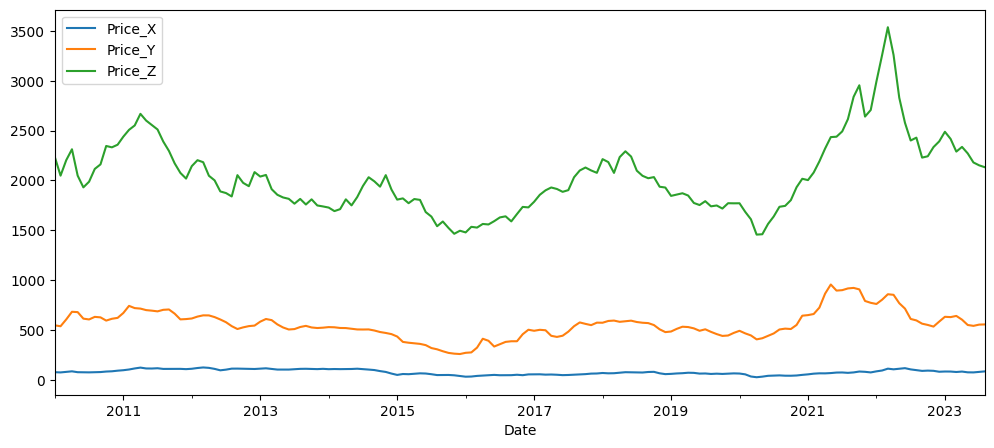

In [ ]:
mensual[['Price_X','Price_Y','Price_Z']].plot(figsize=(12,5))

## Veamos si la series son estacionarias: Esto con el fin de establecer los parametros para el pronostico por medio de un Modelo ARIMA.

In [ ]:
# Estacionariedad

for col in ['Price_X','Price_Y','Price_Z']:

    resultado = adfuller(mensual[col])

    print('\n', col)
    print('ADF Statistic:', round(resultado[0],4))
    print('p-value:', round(resultado[1],4))


 Price_X
ADF Statistic: -1.7539
p-value: 0.4036

 Price_Y
ADF Statistic: -1.9617
p-value: 0.3036

 Price_Z
ADF Statistic: -2.9228
p-value: 0.0428


## Backtesting ARIMA: Este metodo nos permitirá evaluar cual es el periodo de tiempo más adecuado a pronosticar.

In [ ]:
def backtest_arima(serie, order=(1,1,1), test_size=3):

    train = serie[:-test_size]
    test = serie[-test_size:]

    modelo = ARIMA(train, order=order)
    resultado = modelo.fit()

    pred = resultado.forecast(steps=test_size)

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(np.mean((test - pred)**2))
    mape = mean_absolute_percentage_error(test, pred) * 100

    return mae, rmse, mape, pred, test

    # 3 meses
resultados = []

for col in ['Price_X','Price_Y','Price_Z']:

    mae, rmse, mape, pred, test = backtest_arima(mensual[col],order=(1,1,1), test_size=3 )

    resultados.append([ col, round(mae,2),round(rmse,2), round(mape,2) ])

backtest_df = pd.DataFrame(resultados,columns=['Serie','MAE','RMSE','MAPE (%)'])

backtest_df

,Serie,MAE,RMSE,MAPE (%)
0,Price_X,7.56,8.63,9.19
1,Price_Y,18.77,20.09,3.39
2,Price_Z,84.77,87.31,3.94


In [ ]:
# 6 meses

def backtest_arima(serie, order=(1,1,1), test_size=6):

    train = serie[:-test_size]
    test = serie[-test_size:]

    modelo = ARIMA(train, order=order)
    resultado = modelo.fit()

    pred = resultado.forecast(steps=test_size)

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(np.mean((test - pred)**2))
    mape = mean_absolute_percentage_error(test, pred) * 100

    return mae, rmse, mape, pred, test

    # 6 meses
resultados = []

for col in ['Price_X','Price_Y','Price_Z']:
    mae, rmse, mape, pred, test = backtest_arima(mensual[col],order=(1,1,1), test_size=6 )

    resultados.append([ col, round(mae,2),round(rmse,2), round(mape,2) ])

backtest_df = pd.DataFrame(resultados,columns=['Serie','MAE','RMSE','MAPE (%)'])
backtest_df

,Serie,MAE,RMSE,MAPE (%)
0,Price_X,4.03,4.82,5.21
1,Price_Y,53.78,59.46,9.64
2,Price_Z,156.00,173.61,7.13


In [ ]:
# 12 meses


def backtest_arima(serie, order=(1,1,1), test_size=12):

    train = serie[:-test_size]
    test = serie[-test_size:]

    modelo = ARIMA(train, order=order)
    resultado = modelo.fit()

    pred = resultado.forecast(steps=test_size)

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(np.mean((test - pred)**2))
    mape = mean_absolute_percentage_error(test, pred) * 100

    return mae, rmse, mape, pred, test
resultados = []

for col in ['Price_X','Price_Y','Price_Z']:

    mae, rmse, mape, pred, test = backtest_arima(mensual[col], order=(1,1,1), test_size=12)

    resultados.append([col,round(mae,2),round(rmse,2), round(mape,2) ])

backtest_df = pd.DataFrame(
    resultados,
    columns=['Serie','MAE','RMSE','MAPE (%)'])

backtest_df

,Serie,MAE,RMSE,MAPE (%)
0,Price_X,12.53,13.67,15.51
1,Price_Y,46.82,52.80,8.37
2,Price_Z,173.48,198.29,7.78


## El pronostico de 3 meses presenta el menor error promedio de pronóstico (MAPE). A medida que el horizonte aumenta, la precisión disminuye, especialmente para la materia prima X, cuyo error pasa de 9.19% a 15.51% al proyectar 12 meses.

## Con base en lo anterior se procede a hacer el pronostico a 3 meses por medio del Modelo se series de tiempo ARIMA.

## Modelo ARIMA

In [ ]:
# ARIMA
modelo_x = ARIMA(mensual['Price_X'], order=(1,1,1)).fit()
forecast_x = modelo_x.get_forecast(steps=3)

modelo_y = ARIMA(mensual['Price_Y'], order=(1,1,1)).fit()
forecast_y = modelo_y.get_forecast(steps=3)

modelo_z = ARIMA(mensual['Price_Z'], order=(1,1,1)).fit()
forecast_z = modelo_z.get_forecast(steps=3)

In [ ]:
fechas_futuras = pd.date_range( start=mensual.index.max() + pd.offsets.MonthEnd(1),  periods=3, freq='ME')

futuro = pd.DataFrame({'Date': fechas_futuras,'Price_X': forecast_x.predicted_mean.values,'Price_Y': forecast_y.predicted_mean.values,'Price_Z': forecast_z.predicted_mean.values})

futuro

,Date,Price_X,Price_Y,Price_Z
0,2023-09-30,86.284377,554.974129,2127.830850
1,2023-10-31,86.304791,554.870195,2128.344413
2,2023-11-30,86.305145,554.862071,2128.293603


## Ahora procedo a realizar el pronostico del precio de los equipos con base en los pronosticos ya realizados de las materias primas y sus respectivos intervalos de confianza (95%).

In [ ]:
futuro['Pred_Equipo1'] = R1_simple.predict(futuro)
futuro['Pred_Equipo2'] = R2.predict(futuro)
futuro

,Date,Price_X,Price_Y,Price_Z,Pred_Equipo1,Pred_Equipo2
0,2023-09-30,86.284377,554.974129,2127.830850,461.222464,922.515562
1,2023-10-31,86.304791,554.870195,2128.344413,461.143339,922.657796
2,2023-11-30,86.305145,554.862071,2128.293603,461.136908,922.638325


In [ ]:
# Precio Equipo 1

pred_eq1 = R1_simple.get_prediction(futuro)

ic_eq1 = pred_eq1.summary_frame(alpha=0.05)

futuro['Pred_Equipo1'] = ic_eq1['mean']
futuro['IC_Inf_Equipo1'] = ic_eq1['mean_ci_lower']
futuro['IC_Sup_Equipo1'] = ic_eq1['mean_ci_upper']

In [ ]:
# Precio Equipo 2

pred_eq2 = R2.get_prediction(futuro)

ic_eq2 = pred_eq2.summary_frame(alpha=0.05)

futuro['Pred_Equipo2'] = ic_eq2['mean']
futuro['IC_Inf_Equipo2'] = ic_eq2['mean_ci_lower']
futuro['IC_Sup_Equipo2'] = ic_eq2['mean_ci_upper']

##  En la siguiente Tabla se pueden observar los pronosticos de los precios de los equipos para lo proximos 3 meses con sus intervalos de confianza.

In [ ]:
futuro[['Date','Pred_Equipo1','IC_Inf_Equipo1','IC_Sup_Equipo1','Pred_Equipo2','IC_Inf_Equipo2','IC_Sup_Equipo2']]

,Date,Pred_Equipo1,IC_Inf_Equipo1,IC_Sup_Equipo1,Pred_Equipo2,IC_Inf_Equipo2,IC_Sup_Equipo2
0,2023-09-30,461.222464,460.931063,461.513865,922.515562,921.923413,923.107711
1,2023-10-31,461.143339,460.851807,461.434871,922.657796,922.064740,923.250851
2,2023-11-30,461.136908,460.845371,461.428445,922.638325,922.045293,923.231357


## Muestro graficamente los pronosticos de los proximos 3 meses.

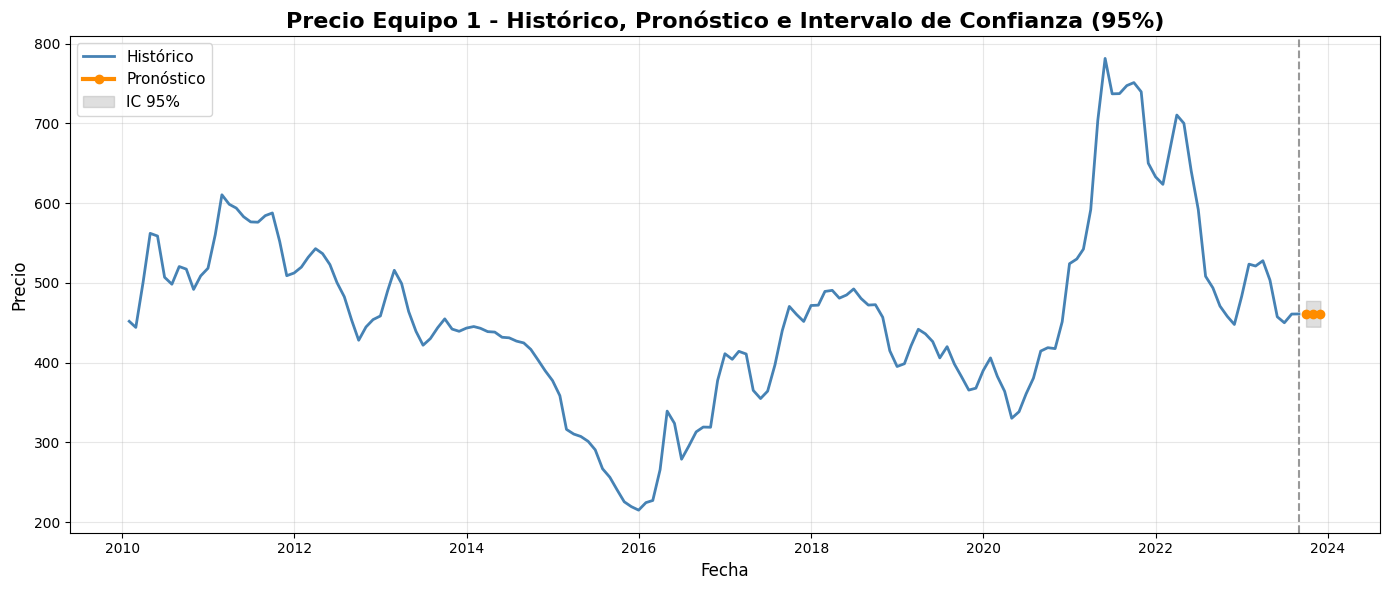

In [ ]:
# Precio Equipo 1

plt.figure(figsize=(14,6))

plt.plot( mensual.index, mensual['Price_Equipo1'], color='steelblue', linewidth=2,  label='Histórico')

plt.plot(futuro['Date'], futuro['Pred_Equipo1'],   color='darkorange', marker='o',  linewidth=3,  label='Pronóstico')

plt.fill_between(futuro['Date'],futuro['IC_Inf_Equipo1'], futuro['IC_Sup_Equipo1'], color='gray',  alpha=0.25,  label='IC 95%')

plt.axvline( x=mensual.index.max(), color='gray', linestyle='--', alpha=0.8)

plt.title( 'Precio Equipo 1 - Histórico, Pronóstico e Intervalo de Confianza (95%)',  fontsize=16, fontweight='bold')

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio', fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

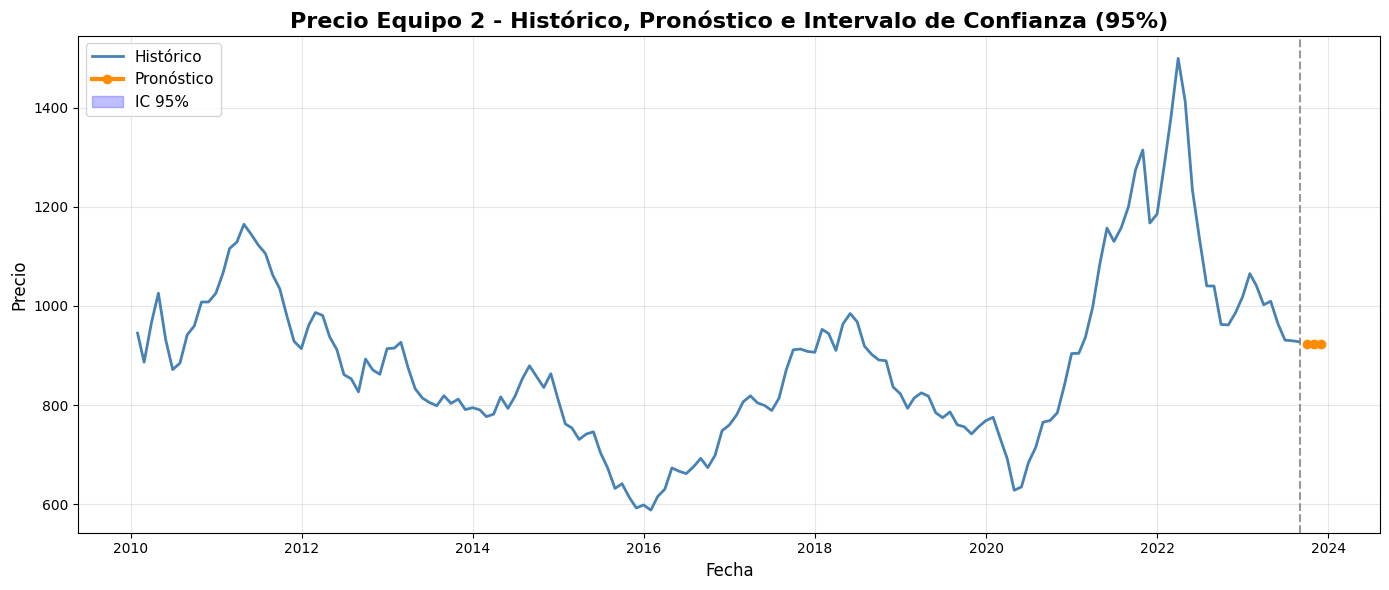

In [ ]:
# Precio Equipo 2

plt.figure(figsize=(14,6))

plt.plot( mensual.index, mensual['Price_Equipo2'], color='steelblue', linewidth=2,  label='Histórico')

plt.plot(futuro['Date'], futuro['Pred_Equipo2'],   color='darkorange', marker='o',  linewidth=3,  label='Pronóstico')

plt.fill_between(futuro['Date'],futuro['IC_Inf_Equipo2'], futuro['IC_Sup_Equipo2'], color='blue',  alpha=0.25,  label='IC 95%')

plt.axvline( x=mensual.index.max(), color='gray', linestyle='--', alpha=0.8)

plt.title( 'Precio Equipo 2 - Histórico, Pronóstico e Intervalo de Confianza (95%)',  fontsize=16, fontweight='bold')

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio', fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()